### Programming for Biomedical Informatics
#### Week 3 - Data Integration & Summary Analysis

Using some of the skills we've developed working with eUtils we're now going to take two different lists of genes that use different identifiers convert them to NCBI Gene IDs and then use these to merge the data together. With the final merged data we will do some calculations and plots.

In [6]:
# Preliminaries
from Bio import Entrez
import urllib.request
import json
import xml.etree.ElementTree as ET

# load my API key from the file
# with open('../api_keys/ncbi.txt', 'r') as file:
#     api_key = file.read().strip()

# with open('../api_keys/ncbi_email.txt', 'r') as file:
#     email = file.read().strip()

api_key = "d0ef4218755c744dc3db26a86be7c77d7208"
email = "L.Chow@sms.ed.ac.uk"

Entrez.api_key = api_key
Entrez.email = email

In [7]:
# Step 1 - Load the two lists that we cannot currenly combine

'''The first file contains a list of gene symbols
path = /Users/lizchow/Desktop/collegeShit/Masters/Programming-for-biomedical-informatics/pbi/week3/GeneSymbols.tsv
e.g.
GeneSymbol
ADAM10
ADAM17
APP
NAE1
APBB1
GAPDH
BACE1

The second file contains a list of RefSeq transcripts (mRNA), and their associated GO terms:
path = /Users/lizchow/Desktop/collegeShit/Masters/Programming-for-biomedical-informatics/pbi/week3/transcript_functions.tsv
e.g.
RefSeqID        GOTerm  Description
NM_001320570    GO:0003824      catalytic activity
NM_001320570    GO:0016787      hydrolase activity
NM_001320570    GO:0140096      catalytic activity, acting on a protein
NM_001320570    GO:0043226      organelle
NM_001320570    GO:0005634      nucleus
NM_001320570    GO:0005794      Golgi apparatus

We are going to convert Gene Symbols and Refseq IDs to NCBI Gene IDs, and then combine the two lists into a single table.
'''
import pandas as pd
# Load the gene symbols as a pandas dataframe
'''### YOUR CODE HERE ###'''

gene_symbols_path = "/Users/lizchow/Desktop/collegeShit/Masters/Programming-for-biomedical-informatics/pbi/week3/GeneSymbols.tsv"
gene_symbols_df = pd.read_csv(gene_symbols_path, sep="\t")

# Load the RefSeq data as a pandas dataframe
'''### YOUR CODE HERE ###'''
refseq_path = "/Users/lizchow/Desktop/collegeShit/Masters/Programming-for-biomedical-informatics/pbi/week3/transcript_functions.tsv"
refseq_df = pd.read_csv(refseq_path, sep="\t")


In [8]:
# view the first few rows of each dataframe
'''### YOUR CODE HERE ###'''
gene_symbols_df.head()

,GeneSymbol
0,ADAM10
1,ADAM17
2,APP
3,NAE1
4,APBB1


In [9]:
# view the first few rows of each dataframe
'''### YOUR CODE HERE ###'''
refseq_df.head()

,RefSeqID,GOTerm,Description
0,NM_001320570,GO:0003824,catalytic activity
1,NM_001320570,GO:0016787,hydrolase activity
2,NM_001320570,GO:0140096,"catalytic activity, acting on a protein"
3,NM_001320570,GO:0043226,organelle
4,NM_001320570,GO:0005634,nucleus


In [10]:
from prettytable import PrettyTable
#Step 2 - Convert Gene Symbols to NCBI Gene IDs

# create a dictionary that maps gene symbols to gene IDs
'''### YOUR CODE HERE ###'''
Entrez.api_key = api_key
Entrez.email = email

gene_symbol_to_id = {}
subset = gene_symbols_df["GeneSymbol"].head(10)

# use eSearch to convert gene symbols to NCBI Gene IDs (for the first 10 gene symbols)
# remembering to add API key and email
# remembering to use the [Gene] field in the search
# remembering to specify human
# show the progress by printing the gene symbol and gene ID and the number of gene symbols processed so far
# This takes about 3 minutes (NB not the quickest way!)
'''### YOUR CODE HERE ###'''
for i, symbol in enumerate(subset, start=1):
    term = f"{symbol}[Gene] AND Homo sapiens[Organism]"
    handle = Entrez.esearch(db="gene", term=term)
    record = Entrez.read(handle)
    handle.close()

    gene_id = record["IdList"][0] if record["IdList"] else None
    gene_symbol_to_id[symbol] = gene_id

#user PrettyTable to display the results
'''### YOUR CODE HERE ###'''
table = PrettyTable()
table.field_names = ["Gene Symbol", "NCBI Gene ID"]

for symbol, gid in gene_symbol_to_id.items():
    table.add_row([symbol, gid])
print(table)


+-------------+--------------+
| Gene Symbol | NCBI Gene ID |
+-------------+--------------+
|    ADAM10   |     102      |
|    ADAM17   |     6868     |
|     APP     |     351      |
|     NAE1    |     8883     |
|    APBB1    |     322      |
|    GAPDH    |     2597     |
|    BACE1    |    23621     |
|    BACE2    |    25825     |
|     RTN3    |    10313     |
|     RTN4    |    57142     |
+-------------+--------------+


In [12]:
# Step 3 - Convert RefSeq IDs to NCBI Gene IDs

# create a dictionary that maps RefSeq IDs to Gene IDs
'''### YOUR CODE HERE ###'''
refseq_to_geneid = {}

# use eSearch to convert RefSeq IDs to NCBI Gene IDs (for the first 10 RefSeq IDs)
# remembering to add API key and email
# remembering to use the [Gene] field in the search
# remembering to specify human

# Search for the gene information using the RefSeq transcript ID
'''### YOUR CODE HERE ###'''
unique_refseqs = refseq_df["RefSeqID"].unique()[:10]

for i, refseq_id in enumerate(unique_refseqs, start=1):
    term = f"{refseq_id}[RefSeq] AND Homo sapiens[Organism]"
    try:
        handle = Entrez.esearch(db="gene", term=term)
        record = Entrez.read(handle)
        handle.close()

        gene_id = record["IdList"][0] if record ["IdList"] else None
        refseq_to_geneid[refseq_id] = gene_id

    except Exception as e:
        refseq_to_geneid[refseq_id] = None

# for the first unique 10 values in the refseq dataframe, get the gene ID
# show the progress by printing the refseq ID and gene ID and the number of refseq IDs processed so far
'''### YOUR CODE HERE ###'''
table = PrettyTable()
table.field_names = ["RefSeq ID", "NCBI Gene ID"]

for rid, gid in refseq_to_geneid.items():
    table.add_row([rid, gid])

In [13]:
#user PrettyTable to display the results
'''### YOUR CODE HERE ###'''
print(table)

+--------------+--------------+
|  RefSeq ID   | NCBI Gene ID |
+--------------+--------------+
| NM_001320570 |     102      |
|  NM_001110   |     102      |
|     nan      |     7421     |
|  NM_003183   |     6868     |
| NM_001382777 |     6868     |
| NM_001382778 |     6868     |
|  NM_175573   |    11047     |
|  NM_007002   |    11047     |
| NM_001281438 |    11047     |
| NM_001281437 |    11047     |
+--------------+--------------+


In [14]:
# Step 4  - merge the refseq_to_gene_id dictionary with the refseq dataframe

# create a new column in the refseq dataframe called 'GeneID'
# fill the column with the gene IDs from the refseq_to_gene_id dictionary
'''### YOUR CODE HERE ###'''
refseq_df["GeneID"] = refseq_df["RefSeqID"].map(refseq_to_geneid)

# remove rows with missing values
'''### YOUR CODE HERE ###'''
refseq_df = refseq_df.dropna(subset=["GeneID"])

# display the refseq dataframe
'''### YOUR CODE HERE ###'''
refseq_df.head()

,RefSeqID,GOTerm,Description,GeneID
0,NM_001320570,GO:0003824,catalytic activity,102
1,NM_001320570,GO:0016787,hydrolase activity,102
2,NM_001320570,GO:0140096,"catalytic activity, acting on a protein",102
3,NM_001320570,GO:0043226,organelle,102
4,NM_001320570,GO:0005634,nucleus,102


In [15]:
#Step 7 - combine the gene_symbol and refseq dataframes

# convert the gene_symbol_to_id dictionary to a dataframe
'''### YOUR CODE HERE ###'''
gene_symbol_to_id_df = pd.DataFrame(list(gene_symbol_to_id.items()), columns=["GeneSymbol", "GeneID"])

# merge the refseq and gene_symbol_to_id_df dataframes on the 'GeneID' column
'''### YOUR CODE HERE ###'''
combined_df = pd.merge(refseq_df, gene_symbol_to_id_df, on="GeneID", how="inner")

# drop the GeneID column
'''### YOUR CODE HERE ###'''   
combined_df = combined_df.drop(columns=["GeneID"])

# display the combined dataframe
'''### YOUR CODE HERE ###'''
combined_df.head()

,RefSeqID,GOTerm,Description,GeneSymbol
0,NM_001320570,GO:0003824,catalytic activity,ADAM10
1,NM_001320570,GO:0016787,hydrolase activity,ADAM10
2,NM_001320570,GO:0140096,"catalytic activity, acting on a protein",ADAM10
3,NM_001320570,GO:0043226,organelle,ADAM10
4,NM_001320570,GO:0005634,nucleus,ADAM10


Combined dataframe shape: (92, 4)
Number of unique genes: 2


/var/folders/hk/65s29z990gxcphls4gf_nz6r0000gn/T/ipykernel_51611/444793827.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="GeneSymbol", y="Num_GO_Terms", palette="Blues_d")


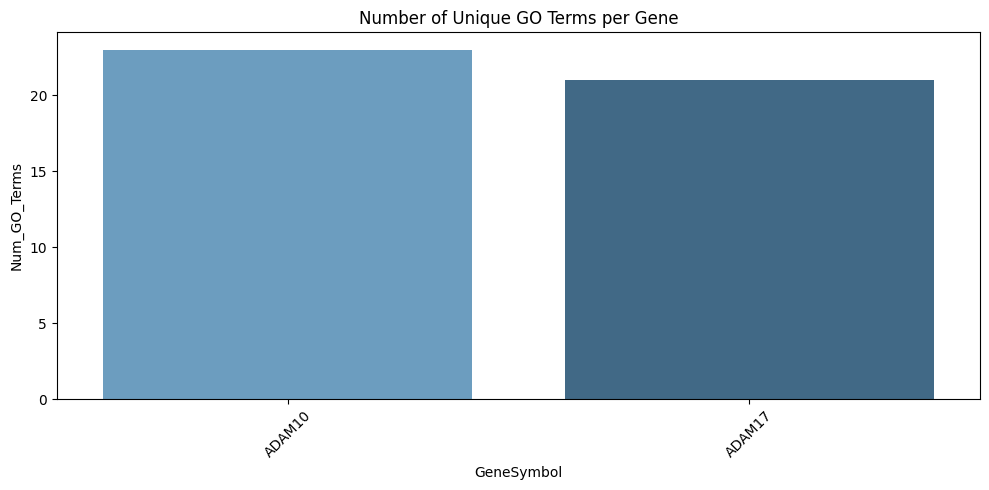

In [17]:
#Step 8 - Do some basic summary analysis

# display the number of rows and columns in the combined dataframe
'''### YOUR CODE HERE ###'''
print(f"Combined dataframe shape: {combined_df.shape}")

# count how many unique genes are in the combined dataframe
'''### YOUR CODE HERE ###'''
unique_genes = combined_df["GeneSymbol"].nunique()

# count how many unique GO terms are in the combined dataframe
'''### YOUR CODE HERE ###'''
unique_go_terms = combined_df["GOTerm"].nunique()

# display the number of unique genes and GO terms
'''### YOUR CODE HERE ###'''
print(f"Number of unique genes: {unique_genes}")

# use some plots to visualise the data (up to you!)
'''### YOUR CODE HERE ###'''
import matplotlib.pyplot as plt
import seaborn as sns
summary = combined_df.groupby("GeneSymbol")["GOTerm"].nunique().reset_index()
summary = summary.rename(columns={"GOTerm": "Num_GO_Terms"})

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="GeneSymbol", y="Num_GO_Terms", palette="Blues_d")
plt.title("Number of Unique GO Terms per Gene")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()